### Import Libraries

In [19]:
# Import required libraries for logistic regression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


### Load Churn Dataset

In [20]:
# Load churn dataset (located in Churn Prediction subfolder)
df = pd.read_csv('Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (667, 20)

First 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


### Explore Dataset

In [21]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution (Churn):")
print(df['Churn'].value_counts())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    str    
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    str    
 4   Voice mail plan         667 non-null    str    
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null   

### Preprocess Data

In [22]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn'].astype(int)  # Convert boolean to binary (True=1, False=0)

# Handle missing values
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=['object']).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

# One-hot encode categorical features
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Preprocessed Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nMissing values after preprocessing (features):", X.isnull().sum().sum())
print("Missing values in target:", y.isnull().sum())

Preprocessed Features shape: (667, 68)
Target shape: (667,)

Missing values after preprocessing (features): 0
Missing values in target: 0


### Split Dataset

In [23]:
# Split into train (80%) and test (20%) sets, stratify to preserve target distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== Dataset Split ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

=== Dataset Split ===
Training samples: 533
Testing samples: 134


### Train Logistic Regression Model

In [24]:
# Train logistic regression model (increase max_iter for convergence)
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("=== Model Trained ===")
print(f"Intercept (log-odds when all features=0): {model.intercept_[0]:.4f}")

=== Model Trained ===
Intercept (log-odds when all features=0): -2.7496


### Interpret Coefficients & Odds Ratio

In [25]:
# Coefficients represent log-odds change per unit feature increase
# Odds Ratio = exp(coefficient) = multiplicative change in odds of churn
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Log-Odds Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
})

print("=== Coefficient Interpretation ===")
print(coef_df.round(4))
print("\nInterpretation:")
print("- Odds Ratio > 1: Feature increases odds of churn")
print("- Odds Ratio < 1: Feature decreases odds of churn")

=== Coefficient Interpretation ===
                   Feature  Log-Odds Coefficient  Odds Ratio
0           Account length               -0.0027      0.9973
1                Area code               -0.0088      0.9912
2    Number vmail messages               -0.0285      0.9719
3        Total day minutes                0.0128      1.0129
4          Total day calls               -0.0020      0.9980
..                     ...                   ...         ...
63                State_WI                0.3862      1.4713
64                State_WV                0.1917      1.2113
65                State_WY               -0.3969      0.6724
66  International plan_Yes                1.5415      4.6716
67     Voice mail plan_Yes               -0.2844      0.7525

[68 rows x 3 columns]

Interpretation:
- Odds Ratio > 1: Feature increases odds of churn
- Odds Ratio < 1: Feature decreases odds of churn


### Evaluate Model Performance

In [26]:
# Predict on test set
y_pred = model.predict(X_test)

print("=== Evaluation Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== Evaluation Metrics ===
Accuracy: 0.8433
Precision: 0.3333
Recall: 0.1053

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.97      0.91       115
       Churn       0.33      0.11      0.16        19

    accuracy                           0.84       134
   macro avg       0.60      0.54      0.54       134
weighted avg       0.79      0.84      0.81       134



### ROC Curve & AUC

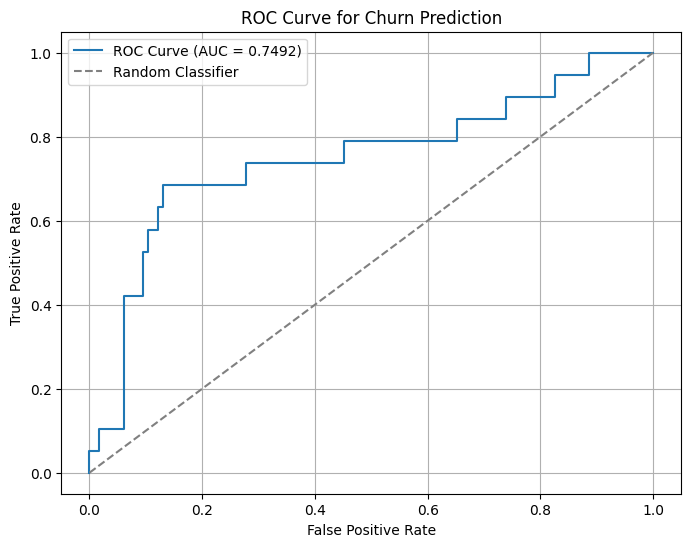

AUC Score: 0.7492


In [27]:
# Calculate ROC curve and AUC
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of churn class
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Churn Prediction')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score: {auc_score:.4f}")